# **Exercício 01  - Uso da PDD (Extração de Dados, limpeza e análise)**

## **Programa de pós-graduação em Biotenologias em Saúde e Medicina Investigativa - FIOCRUZ BAHIA**
### Disciplina: Tópicos Introdutórios à Ciência de Dados para Saúde
### Estudante: Danilo Dias 

**OBJETIVO**: Capacitar o(a) aluno(a) para utilizar a Plataforma deDadosDesidentificados (PDD-Cidacs) como fonte de extração e integraçãodedadosadministrativos abertos, aplicando procedimentos de obtenção, filtrageme organizaçãodebases de dados voltadas à análise de dados para saúde. A atividade visadesenvolverhabilidades práticas na construção de uma base de dados estruturada paraestudosepidemiológicos e socioeconômicos, integrando variáveis de desfecho e determinantessociais da saúde.

**DESCRIÇÃO**: nesta atividade, o(a) aluno(a) deverá, por meio daplataforma(https://pdd.cidacs.org/), realizar o download das bases de dados necessárias, aplicandocorretamente os filtros de seleção de acordo com a proposta da prática (incluindooscritérios de população, abrangência temporal, geográfica e de seleção de variáveis). Alémdisso, deverá estruturar uma base de dados final para análise. 

## Importação de Bibliotecas necessárias para o estudo

In [166]:
!pip install geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.4/338.4 kB 3.9 MB/s eta 0:00:003.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.7/27.7 MB 20.8 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 19.6 MB/s eta 0:00:000:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 20.7 MB/s eta 0:00:0031m21.7 MB/s eta 0:00:01


In [183]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
import glob
import statsmodels.api as sm
import contextily as ctx
from pdd_lib.bib_pdd_cidacs import BibPddCidacs

In [170]:
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)

## listagem dos arquivos presentes no ambiente de trabalho

In [168]:
!pip install contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.4/125.4 kB 2.1 MB/s eta 0:00:00MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 11.5 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.7/92.7 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 5.4 MB/s eta 0:00:00


In [89]:
os.listdir('../DATA/')

['mun_raca_cor.csv',
 'ibp.csv',
 'economicos_e_sociodemograficos.csv',
 'SIM_2000_2023.csv.gzip',
 'regioes_de_saude_do_brasil_(shapefile)___2025.csv',
 'SINASC_2000_2023.csv.gzip',
 'macrorregioes_de_saude_do_brasil_(shapefile)___2025.csv']

## Utilizando a PDD obtivemos as seguintes bases de dados:  

 -  mun_raca_cor.csv,
 - ibp.csv,
 -  economicos_e_sociodemograficos.csv,
 -  SIM_2000_2023.csv.gzip,
 - regioes_de_saude_do_brasil_(shapefile)___2025.csv,
 -  SINASC_2000_2023.csv.gzip,
 -  macrorregioes_de_saude_do_brasil_(shapefile)___2025.csv


## Para obtenção dos arquivos em formato .csv, foram aplicados filtros temporais, bem como a seleção dos registros apenas oriundos do estado de Minas Gerais. 

## Leitura dos arquivos presentes no ambiente de trabalho

In [90]:
 sim = pd.read_csv("../DATA/SIM_2000_2023.csv.gzip", compression="gzip", header=0, sep = ',')

In [91]:
sinasc = pd.read_csv("../DATA/SINASC_2000_2023.csv.gzip", compression = "gzip", low_memory=False, header=0, sep=',')

In [92]:
ibp = pd.read_csv('../DATA/ibp.csv', header=0, sep=',')

In [93]:
econ_sociodemo = pd.read_csv('../DATA/economicos_e_sociodemograficos.csv', header=0, sep=',')

In [94]:
mun_raca_cor = pd.read_csv('../DATA/mun_raca_cor.csv', header=0, sep=',')

## Informações básicas das duas principais bases de dados (SIM e SINASC)

In [95]:
sim.head()

,SEXO,DTNASC,DATANASC,CODMUNRES,DTOBITO
0,0,NaN,NaN,316470,21032022
1,0,NaN,NaN,312160,13102018
2,0,NaN,NaN,3148400,24062000
3,0,NaN,NaN,3162807,24112003
4,0,1012009.0,NaN,317052,30122009


In [96]:
sim.tail()

,SEXO,DTNASC,DATANASC,CODMUNRES,DTOBITO
85357,9,26052011.0,NaN,311860,31052011
85358,9,26072011.0,NaN,311120,26072011
85359,9,27042011.0,NaN,316690,5052011
85360,9,27062011.0,NaN,311800,28062011
85361,9,29012011.0,NaN,310620,2022011


In [97]:
sinasc.head()

,SEXO,DTNASC,CODMUNNASC
0,0,01012001,3121605
1,0,01012023,317020
2,0,01042005,3118304
3,0,01062000,3171204
4,0,01072012,310560


In [98]:
sinasc.tail()

,SEXO,DTNASC,CODMUNNASC
6326291,M,31122014,316210
6326292,M,31122014,310860
6326293,M,31122014,310670
6326294,M,31122014,310620
6326295,M,31122014,311430


## Tabela contendo as principais informações nas bases de dados selecionadas para composição do estudo

In [99]:
dicionario = {
    "base" : ["sinasc", "sim", "ibp", "econ_sociodemo", "mun_raca_cor"],
    "número de linhas" : [sinasc.shape[0], sim.shape[0], ibp.shape[0], econ_sociodemo.shape[0], mun_raca_cor.shape[0]],
    "número de colunas": [sinasc.shape[1], sim.shape[1], ibp.shape[1], econ_sociodemo.shape[1], mun_raca_cor.shape[1]],
    "colunas" :[str(sinasc.columns).replace("Index([", "").replace("], dtype='object')", ""), str(sim.columns).replace("Index([", "").replace("], dtype='object')", ""), str(ibp.columns).replace("Index([", "").replace("], dtype='object')", ""), str(econ_sociodemo.columns).replace("Index([", "").replace("], dtype='object')", "")
, str(mun_raca_cor.columns).replace("Index([", "").replace("], dtype='object')", "")]
}

tabela = pd.DataFrame(dicionario)
tabela

,base,número de linhas,número de colunas,colunas
0,sinasc,6326296,3,"'SEXO', 'DTNASC', 'CODMUNNASC'"
1,sim,85362,5,"'SEXO', 'DTNASC', 'DATANASC', 'CODMUNRES', 'DTOBITO'"
2,ibp,5565,9,"'nome_grande_regiao', 'uf', 'nome_da_uf', 'cod_municipio', 'codmun6', 'nome_do_municipio', 'measure_1f_12', 'd_measure_1f_12', 'q_measure_1f_12'"
3,econ_sociodemo,5570,27,"'ibge_code', 'mun', 'state_cod', 'state', 'region', 'pop_total', 'pop_rural', 'pop_urbana', 'popporte', 'idhm', 'idhm_renda', 'idhm_longevidade', 'idhm_educacao', 'pib_milhao',\n 'pibpercapita_mil', 'renda', 'renda_gini', 'analfa_total', 'analfa_mulher', 'esc_anos', 'desemprego', 'pobres', 'extr_pobres', 'percent_domicilios_banheiro_agua_encanada',\n 'percent_domicilios_coleta_lixo', 'percent_domicilios_energia_eletrica', 'percent_domicilios_com_densidade_maior_que_2'],\n dtype='object')"
4,mun_raca_cor,5571,11,"'codigo_regiao_do_pais', 'regiao_do_pais', 'codigo_uf', 'uf', 'codigo_macrorregiao_de_saude', 'macrorregiao_de_saude', 'codigo_regiao_de_saude', 'regiao_de_saude', 'codigo_municipio',\n 'municipio', 'populacao_estimada_ibge_2022'],\n dtype='object')"


## Tratamento dos dados

primeiramente tratamos os dados relativos aos códigos de municípios, para que estes sejam transformados apenas em dados com seis dígitos.

In [100]:
sinasc["CODMUNNASC"] = sinasc["CODMUNNASC"].astype(str).str[:6]
sim["CODMUNRES"] = sim["CODMUNRES"].astype(str).str[:6]

criamos a variável chamada "ano" a partir dos 4 dígitos presentes na variável "DTOBITO".

In [101]:
sim["ANO"] = sim["DTOBITO"].astype(str).str[-4:]

In [102]:
sim.head()

,SEXO,DTNASC,DATANASC,CODMUNRES,DTOBITO,ANO
0,0,NaN,NaN,316470,21032022,2022
1,0,NaN,NaN,312160,13102018,2018
2,0,NaN,NaN,314840,24062000,2000
3,0,NaN,NaN,316280,24112003,2003
4,0,1012009.0,NaN,317052,30122009,2009


## Agregamos os dados a partir dos códigos de municípios e anos, para ser possível calcular a taxa de mortalidade no futuro.

In [103]:
sim_agg = (sim 
    .groupby(["CODMUNRES", "ANO"], as_index=False)
    .size()                                             
    .rename(columns={"size": "n_obitos"})               
)

In [104]:
sim_agg.head()

,CODMUNRES,ANO,n_obitos
0,310000,2000,11
1,310000,2001,2
2,310000,2002,3
3,310000,2004,4
4,310000,2005,4


In [105]:
sim_agg.tail()

,CODMUNRES,ANO,n_obitos
14561,317220,2003,2
14562,317220,2004,2
14563,317220,2011,1
14564,317220,2012,1
14565,317220,2013,1


In [106]:
len(sim_agg)

14566

In [107]:
sinasc["ANO"] = sinasc["DTNASC"].astype(str).str[-4:]

### Na nossa base de dados do SINASC, filtramos os dados apenas para os municípios correspondentes ao estado de Minas Gerais, representados pelo código 31, em seguida também agregamos os dados do SINASC por código de município e ano, visando realizar o link entre as bases (SIM e SINASC), bem como o cálculo da taxa de mortalidade infantil.

In [108]:
sinasc = sinasc[
    sinasc["CODMUNNASC"].astype(str).str.startswith("31")
]

In [109]:
sinasc_agg = (sinasc
    .groupby(["CODMUNNASC", "ANO"], as_index=False)
    .size()                                             
    .rename(columns={"size": "n_nascimentos"})               
)

In [110]:
sinasc_agg

,CODMUNNASC,ANO,n_nascimentos
0,310000,2000,1
1,310010,2000,99
2,310010,2001,73
3,310010,2002,64
4,310010,2003,60
...,...,...,...
12275,317210,2009,5
12276,317210,2014,1
12277,317210,2015,1
12278,317210,2017,4


## Joins de bases de dados, mediante as variáveis ano e código do município.

In [111]:
df_join = pd.merge(
    sinasc_agg,
    sim_agg,
    left_on=["CODMUNNASC", "ANO"],
    right_on=["CODMUNRES", "ANO"],
    how="left"
)

In [112]:
df_join

,CODMUNNASC,ANO,n_nascimentos,CODMUNRES,n_obitos
0,310000,2000,1,310000,11.0
1,310010,2000,99,310010,2.0
2,310010,2001,73,NaN,NaN
3,310010,2002,64,310010,2.0
4,310010,2003,60,NaN,NaN
...,...,...,...,...,...
12275,317210,2009,5,NaN,NaN
12276,317210,2014,1,317210,1.0
12277,317210,2015,1,NaN,NaN
12278,317210,2017,4,317210,1.0


In [113]:
df_join["CODMUNRES"] = pd.to_numeric(df_join["CODMUNRES"], errors="coerce").astype("Int64")

In [114]:
df_join = pd.merge(
    df_join, 
    ibp,
    left_on=["CODMUNRES"],
    right_on=["codmun6"],
    how="left"
    
)

In [115]:
df_join = df_join.drop(['nome_grande_regiao', 'measure_1f_12', 'd_measure_1f_12','q_measure_1f_12'], axis = 1)

In [116]:
df_join = df_join.loc[df_join['codmun6'].notna()]

In [117]:
df_join['n_obitos']=df_join['n_obitos'].astype(int)

In [118]:
df_join.head()

,CODMUNNASC,ANO,n_nascimentos,CODMUNRES,n_obitos,uf,nome_da_uf,cod_municipio,codmun6,nome_do_municipio
1,310010,2000,99,310010,2,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS
3,310010,2002,64,310010,2,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS
5,310010,2004,83,310010,1,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS
7,310010,2006,86,310010,2,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS
8,310010,2007,90,310010,1,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS


In [119]:
df_join['taxa_de_mortalidade_infantil'] = (df_join['n_obitos']/df_join['n_nascimentos']) * 1000

In [120]:
df_join.head()

,CODMUNNASC,ANO,n_nascimentos,CODMUNRES,n_obitos,uf,nome_da_uf,cod_municipio,codmun6,nome_do_municipio,taxa_de_mortalidade_infantil
1,310010,2000,99,310010,2,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS,20.202020
3,310010,2002,64,310010,2,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS,31.250000
5,310010,2004,83,310010,1,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS,12.048193
7,310010,2006,86,310010,2,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS,23.255814
8,310010,2007,90,310010,1,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS,11.111111


In [121]:
df_join.tail()

,CODMUNNASC,ANO,n_nascimentos,CODMUNRES,n_obitos,uf,nome_da_uf,cod_municipio,codmun6,nome_do_municipio,taxa_de_mortalidade_infantil
12272,317210,2006,7,317210,2,31.0,Minas Gerais,3172103.0,317210.0,VOLTA GRANDE,285.714286
12273,317210,2007,4,317210,1,31.0,Minas Gerais,3172103.0,317210.0,VOLTA GRANDE,250.000000
12276,317210,2014,1,317210,1,31.0,Minas Gerais,3172103.0,317210.0,VOLTA GRANDE,1000.000000
12278,317210,2017,4,317210,1,31.0,Minas Gerais,3172103.0,317210.0,VOLTA GRANDE,250.000000
12279,317210,2018,1,317210,1,31.0,Minas Gerais,3172103.0,317210.0,VOLTA GRANDE,1000.000000


## Agregações finais - dados demográficos e socioeconômicos 
-- aqui agregramos os dados econômicos e sociodemográficos presentes nas demais bases de dados. 

In [122]:
mun_raca_cor = mun_raca_cor[
    mun_raca_cor["codigo_municipio"].astype(str).str.startswith("31")
]

In [123]:
econ_sociodemo = econ_sociodemo[
    econ_sociodemo["ibge_code"].astype(str).str.startswith("31")
]

In [124]:
df_join = pd.merge(
    df_join, 
    econ_sociodemo, 
    left_on = 'CODMUNRES', 
    right_on = 'ibge_code', 
    how = 'left'
)

In [125]:
df_join = pd.merge(
    df_join, 
    mun_raca_cor, 
    left_on = 'CODMUNRES', 
    right_on = 'codigo_municipio', 
    how='left'
)

In [126]:
df_join.head()

,CODMUNNASC,ANO,n_nascimentos,CODMUNRES,n_obitos,uf_x,nome_da_uf,cod_municipio,codmun6,nome_do_municipio,taxa_de_mortalidade_infantil,ibge_code,mun,state_cod,state,region,pop_total,pop_rural,pop_urbana,popporte,idhm,idhm_renda,idhm_longevidade,idhm_educacao,pib_milhao,pibpercapita_mil,renda,renda_gini,analfa_total,analfa_mulher,esc_anos,desemprego,pobres,extr_pobres,percent_domicilios_banheiro_agua_encanada,percent_domicilios_coleta_lixo,percent_domicilios_energia_eletrica,percent_domicilios_com_densidade_maior_que_2,codigo_regiao_do_pais,regiao_do_pais,codigo_uf,uf_y,codigo_macrorregiao_de_saude,macrorregiao_de_saude,codigo_regiao_de_saude,regiao_de_saude,codigo_municipio,municipio,populacao_estimada_ibge_2022
0,310010,2000,99,310010,2,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS,20.202020,310010,ABADIA DOS DOURADOS,31,MG,SUDESTE,6704.0,2515.0,4189.0,Pequeno Porte I,0.689,0.693,0.839,0.563,63.672,9.497613,592.68,0.4738,7.9,8.0,8.68,3.79,7.94,1.85,98.18,98.03,98.55,8.62,3,Sudeste,31,Minas Gerais,3113,TRIANGULO DO NORTE,31074,PATROCINIO MONTE CARMELO,310010,Abadia dos Dourados,6.272
1,310010,2002,64,310010,2,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS,31.250000,310010,ABADIA DOS DOURADOS,31,MG,SUDESTE,6704.0,2515.0,4189.0,Pequeno Porte I,0.689,0.693,0.839,0.563,63.672,9.497613,592.68,0.4738,7.9,8.0,8.68,3.79,7.94,1.85,98.18,98.03,98.55,8.62,3,Sudeste,31,Minas Gerais,3113,TRIANGULO DO NORTE,31074,PATROCINIO MONTE CARMELO,310010,Abadia dos Dourados,6.272
2,310010,2004,83,310010,1,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS,12.048193,310010,ABADIA DOS DOURADOS,31,MG,SUDESTE,6704.0,2515.0,4189.0,Pequeno Porte I,0.689,0.693,0.839,0.563,63.672,9.497613,592.68,0.4738,7.9,8.0,8.68,3.79,7.94,1.85,98.18,98.03,98.55,8.62,3,Sudeste,31,Minas Gerais,3113,TRIANGULO DO NORTE,31074,PATROCINIO MONTE CARMELO,310010,Abadia dos Dourados,6.272
3,310010,2006,86,310010,2,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS,23.255814,310010,ABADIA DOS DOURADOS,31,MG,SUDESTE,6704.0,2515.0,4189.0,Pequeno Porte I,0.689,0.693,0.839,0.563,63.672,9.497613,592.68,0.4738,7.9,8.0,8.68,3.79,7.94,1.85,98.18,98.03,98.55,8.62,3,Sudeste,31,Minas Gerais,3113,TRIANGULO DO NORTE,31074,PATROCINIO MONTE CARMELO,310010,Abadia dos Dourados,6.272
4,310010,2007,90,310010,1,31.0,Minas Gerais,3100104.0,310010.0,ABADIA DOS DOURADOS,11.111111,310010,ABADIA DOS DOURADOS,31,MG,SUDESTE,6704.0,2515.0,4189.0,Pequeno Porte I,0.689,0.693,0.839,0.563,63.672,9.497613,592.68,0.4738,7.9,8.0,8.68,3.79,7.94,1.85,98.18,98.03,98.55,8.62,3,Sudeste,31,Minas Gerais,3113,TRIANGULO DO NORTE,31074,PATROCINIO MONTE CARMELO,310010,Abadia dos Dourados,6.272


In [127]:
df_join.tail()

,CODMUNNASC,ANO,n_nascimentos,CODMUNRES,n_obitos,uf_x,nome_da_uf,cod_municipio,codmun6,nome_do_municipio,taxa_de_mortalidade_infantil,ibge_code,mun,state_cod,state,region,pop_total,pop_rural,pop_urbana,popporte,idhm,idhm_renda,idhm_longevidade,idhm_educacao,pib_milhao,pibpercapita_mil,renda,renda_gini,analfa_total,analfa_mulher,esc_anos,desemprego,pobres,extr_pobres,percent_domicilios_banheiro_agua_encanada,percent_domicilios_coleta_lixo,percent_domicilios_energia_eletrica,percent_domicilios_com_densidade_maior_que_2,codigo_regiao_do_pais,regiao_do_pais,codigo_uf,uf_y,codigo_macrorregiao_de_saude,macrorregiao_de_saude,codigo_regiao_de_saude,regiao_de_saude,codigo_municipio,municipio,populacao_estimada_ibge_2022
10246,317210,2006,7,317210,2,31.0,Minas Gerais,3172103.0,317210.0,VOLTA GRANDE,285.714286,317210,VOLTA GRANDE,31,MG,SUDESTE,5070.0,1268.0,3802.0,Pequeno Porte I,0.669,0.669,0.841,0.531,103.455,20.405325,503.51,0.523,12.5,12.2,8.01,6.79,15.66,5.45,100.0,95.86,99.87,28.99,3,Sudeste,31,Minas Gerais,3107,SUDESTE,31041,ALEM PARAIBA,317210,Volta Grande,4.443
10247,317210,2007,4,317210,1,31.0,Minas Gerais,3172103.0,317210.0,VOLTA GRANDE,250.000000,317210,VOLTA GRANDE,31,MG,SUDESTE,5070.0,1268.0,3802.0,Pequeno Porte I,0.669,0.669,0.841,0.531,103.455,20.405325,503.51,0.523,12.5,12.2,8.01,6.79,15.66,5.45,100.0,95.86,99.87,28.99,3,Sudeste,31,Minas Gerais,3107,SUDESTE,31041,ALEM PARAIBA,317210,Volta Grande,4.443
10248,317210,2014,1,317210,1,31.0,Minas Gerais,3172103.0,317210.0,VOLTA GRANDE,1000.000000,317210,VOLTA GRANDE,31,MG,SUDESTE,5070.0,1268.0,3802.0,Pequeno Porte I,0.669,0.669,0.841,0.531,103.455,20.405325,503.51,0.523,12.5,12.2,8.01,6.79,15.66,5.45,100.0,95.86,99.87,28.99,3,Sudeste,31,Minas Gerais,3107,SUDESTE,31041,ALEM PARAIBA,317210,Volta Grande,4.443
10249,317210,2017,4,317210,1,31.0,Minas Gerais,3172103.0,317210.0,VOLTA GRANDE,250.000000,317210,VOLTA GRANDE,31,MG,SUDESTE,5070.0,1268.0,3802.0,Pequeno Porte I,0.669,0.669,0.841,0.531,103.455,20.405325,503.51,0.523,12.5,12.2,8.01,6.79,15.66,5.45,100.0,95.86,99.87,28.99,3,Sudeste,31,Minas Gerais,3107,SUDESTE,31041,ALEM PARAIBA,317210,Volta Grande,4.443
10250,317210,2018,1,317210,1,31.0,Minas Gerais,3172103.0,317210.0,VOLTA GRANDE,1000.000000,317210,VOLTA GRANDE,31,MG,SUDESTE,5070.0,1268.0,3802.0,Pequeno Porte I,0.669,0.669,0.841,0.531,103.455,20.405325,503.51,0.523,12.5,12.2,8.01,6.79,15.66,5.45,100.0,95.86,99.87,28.99,3,Sudeste,31,Minas Gerais,3107,SUDESTE,31041,ALEM PARAIBA,317210,Volta Grande,4.443


## Agora que possuímos uma base de dados mais robusta, faremos a limpeza de variáveis com mesmo significado, bem como o tratamento dos tipos de dados, isto é importante para realização de operações com os daos.

In [128]:
df_join.drop(['uf_x','uf_y', 'nome_da_uf', 'codigo_municipio', 'CODMUNNASC', 'codmun6'], axis=1, inplace=True)

## A nossa base de dados agora possui 43 variáveis

In [129]:
len(df_join.columns)

43

In [131]:
df_join.columns

Index(['ANO', 'n_nascimentos', 'CODMUNRES', 'n_obitos', 'cod_municipio', 'nome_do_municipio', 'taxa_de_mortalidade_infantil', 'ibge_code', 'mun', 'state_cod', 'state', 'region', 'pop_total',
       'pop_rural', 'pop_urbana', 'popporte', 'idhm', 'idhm_renda', 'idhm_longevidade', 'idhm_educacao', 'pib_milhao', 'pibpercapita_mil', 'renda', 'renda_gini', 'analfa_total', 'analfa_mulher',
       'esc_anos', 'desemprego', 'pobres', 'extr_pobres', 'percent_domicilios_banheiro_agua_encanada', 'percent_domicilios_coleta_lixo', 'percent_domicilios_energia_eletrica',
       'percent_domicilios_com_densidade_maior_que_2', 'codigo_regiao_do_pais', 'regiao_do_pais', 'codigo_uf', 'codigo_macrorregiao_de_saude', 'macrorregiao_de_saude', 'codigo_regiao_de_saude',
       'regiao_de_saude', 'municipio', 'populacao_estimada_ibge_2022'],
      dtype='object')

In [139]:
text_variables = ['mun','nome_do_municipio','state','region','regiao_do_pais', 'popporte', 'macrorregiao_de_saude', 'regiao_de_saude', 'municipio']

df_join[text_variables] = df_join[text_variables].astype(str)

In [152]:
df_join[variable] = df_join[variable].str.replace('.', '', regex=False).astype(float)

## A partir daqui podemos explorar os dados e fazer algumas análises...

In [154]:
df_join.sort_values(by='idhm', ascending=False)

,ANO,n_nascimentos,CODMUNRES,n_obitos,cod_municipio,nome_do_municipio,taxa_de_mortalidade_infantil,ibge_code,mun,state_cod,state,region,pop_total,pop_rural,pop_urbana,popporte,idhm,idhm_renda,idhm_longevidade,idhm_educacao,pib_milhao,pibpercapita_mil,renda,renda_gini,analfa_total,analfa_mulher,esc_anos,desemprego,pobres,extr_pobres,percent_domicilios_banheiro_agua_encanada,percent_domicilios_coleta_lixo,percent_domicilios_energia_eletrica,percent_domicilios_com_densidade_maior_que_2,codigo_regiao_do_pais,regiao_do_pais,codigo_uf,codigo_macrorregiao_de_saude,macrorregiao_de_saude,codigo_regiao_de_saude,regiao_de_saude,municipio,populacao_estimada_ibge_2022
6516,2022,4131,314480,14,3144805.0,NOVA LIMA,3.389010,314480,NOVA LIMA,31,MG,SUDESTE,80998.0,1766.0,79232.0,Médio Porte,0.813,0.864,0.885,0.704,5382.564,66.453049,1709.89,0.6914,2.9,3.2,9.77,4.97,2.84,0.51,97.72,99.58,99.70,18.16,3,Sudeste,31,3103,CENTRO,31016,BELO HORIZONTE NOVA LIMA SANTA LUZIA,Nova Lima,111697.0
6502,2008,5221,314480,13,3144805.0,NOVA LIMA,2.489944,314480,NOVA LIMA,31,MG,SUDESTE,80998.0,1766.0,79232.0,Médio Porte,0.813,0.864,0.885,0.704,5382.564,66.453049,1709.89,0.6914,2.9,3.2,9.77,4.97,2.84,0.51,97.72,99.58,99.70,18.16,3,Sudeste,31,3103,CENTRO,31016,BELO HORIZONTE NOVA LIMA SANTA LUZIA,Nova Lima,111697.0
6517,2023,4267,314480,15,3144805.0,NOVA LIMA,3.515350,314480,NOVA LIMA,31,MG,SUDESTE,80998.0,1766.0,79232.0,Médio Porte,0.813,0.864,0.885,0.704,5382.564,66.453049,1709.89,0.6914,2.9,3.2,9.77,4.97,2.84,0.51,97.72,99.58,99.70,18.16,3,Sudeste,31,3103,CENTRO,31016,BELO HORIZONTE NOVA LIMA SANTA LUZIA,Nova Lima,111697.0
6515,2021,3423,314480,9,3144805.0,NOVA LIMA,2.629273,314480,NOVA LIMA,31,MG,SUDESTE,80998.0,1766.0,79232.0,Médio Porte,0.813,0.864,0.885,0.704,5382.564,66.453049,1709.89,0.6914,2.9,3.2,9.77,4.97,2.84,0.51,97.72,99.58,99.70,18.16,3,Sudeste,31,3103,CENTRO,31016,BELO HORIZONTE NOVA LIMA SANTA LUZIA,Nova Lima,111697.0
6514,2020,3711,314480,7,3144805.0,NOVA LIMA,1.886284,314480,NOVA LIMA,31,MG,SUDESTE,80998.0,1766.0,79232.0,Médio Porte,0.813,0.864,0.885,0.704,5382.564,66.453049,1709.89,0.6914,2.9,3.2,9.77,4.97,2.84,0.51,97.72,99.58,99.70,18.16,3,Sudeste,31,3103,CENTRO,31016,BELO HORIZONTE NOVA LIMA SANTA LUZIA,Nova Lima,111697.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8932,2018,26,316245,1,3162450.0,SÃO JOÃO DAS MISSÕES,38.461538,316245,SAO JOAO DAS MISSOES,31,MG,SUDESTE,11715.0,9269.0,2446.0,Pequeno Porte I,0.529,0.502,0.776,0.381,38.074,3.250021,177.36,0.5225,29.0,27.8,7.09,12.63,53.37,33.88,43.70,85.48,83.16,45.48,3,Sudeste,31,3108,NORTE,31076,MANGA,Sao Joao das Missoes,13024.0
8933,2019,7,316245,8,3162450.0,SÃO JOÃO DAS MISSÕES,1142.857143,316245,SAO JOAO DAS MISSOES,31,MG,SUDESTE,11715.0,9269.0,2446.0,Pequeno Porte I,0.529,0.502,0.776,0.381,38.074,3.250021,177.36,0.5225,29.0,27.8,7.09,12.63,53.37,33.88,43.70,85.48,83.16,45.48,3,Sudeste,31,3108,NORTE,31076,MANGA,Sao Joao das Missoes,13024.0
8934,2020,21,316245,3,3162450.0,SÃO JOÃO DAS MISSÕES,142.857143,316245,SAO JOAO DAS MISSOES,31,MG,SUDESTE,11715.0,9269.0,2446.0,Pequeno Porte I,0.529,0.502,0.776,0.381,38.074,3.250021,177.36,0.5225,29.0,27.8,7.09,12.63,53.37,33.88,43.70,85.48,83.16,45.48,3,Sudeste,31,3108,NORTE,31076,MANGA,Sao Joao das Missoes,13024.0
8935,2021,18,316245,2,3162450.0,SÃO JOÃO DAS MISSÕES,111.111111,316245,SAO JOAO DAS MISSOES,31,MG,SUDESTE,11715.0,9269.0,2446.0,Pequeno Porte I,0.529,0.502,0.776,0.381,38.074,3.250021,177.36,0.5225,29.0,27.8,7.09,12.63,53.37,33.88,43.70,85.48,83.16,45.48,3,Sudeste,31,3108,NORTE,31076,MANGA,Sao Joao das Missoes,13024.0


## Avaliação e comparação das taxas de mortalidade em função do IDH-M

Dois municípios com IDH-M muito alto. 

In [59]:
df_join.loc[df_join['nome_do_municipio']=='NOVA LIMA'].head()

,ANO,n_nascimentos,CODMUNRES,n_obitos,cod_municipio,nome_do_municipio,taxa_de_mortalidade_infantil,ibge_code,mun,state_cod,state,region,pop_total,pop_rural,pop_urbana,popporte,idhm,idhm_renda,idhm_longevidade,idhm_educacao,pib_milhao,pibpercapita_mil,renda,renda_gini,analfa_total,analfa_mulher,esc_anos,desemprego,pobres,extr_pobres,percent_domicilios_banheiro_agua_encanada,percent_domicilios_coleta_lixo,percent_domicilios_energia_eletrica,percent_domicilios_com_densidade_maior_que_2,codigo_regiao_do_pais,regiao_do_pais,codigo_uf,codigo_macrorregiao_de_saude,macrorregiao_de_saude,codigo_regiao_de_saude,regiao_de_saude,municipio,populacao_estimada_ibge_2022
6494,2000,1730,314480,14,3144805.0,NOVA LIMA,8.092486,314480,NOVA LIMA,31,MG,SUDESTE,80998.0,1766.0,79232.0,Médio Porte,0.813,0.864,0.885,0.704,5382.564,66.453049,1709.89,0.6914,2.9,3.2,9.77,4.97,2.84,0.51,97.72,99.58,99.7,18.16,3,Sudeste,31,3103,CENTRO,31016,BELO HORIZONTE NOVA LIMA SANTA LUZIA,Nova Lima,111.697
6495,2001,2695,314480,25,3144805.0,NOVA LIMA,9.276438,314480,NOVA LIMA,31,MG,SUDESTE,80998.0,1766.0,79232.0,Médio Porte,0.813,0.864,0.885,0.704,5382.564,66.453049,1709.89,0.6914,2.9,3.2,9.77,4.97,2.84,0.51,97.72,99.58,99.7,18.16,3,Sudeste,31,3103,CENTRO,31016,BELO HORIZONTE NOVA LIMA SANTA LUZIA,Nova Lima,111.697
6496,2002,3142,314480,13,3144805.0,NOVA LIMA,4.137492,314480,NOVA LIMA,31,MG,SUDESTE,80998.0,1766.0,79232.0,Médio Porte,0.813,0.864,0.885,0.704,5382.564,66.453049,1709.89,0.6914,2.9,3.2,9.77,4.97,2.84,0.51,97.72,99.58,99.7,18.16,3,Sudeste,31,3103,CENTRO,31016,BELO HORIZONTE NOVA LIMA SANTA LUZIA,Nova Lima,111.697
6497,2003,3265,314480,17,3144805.0,NOVA LIMA,5.206738,314480,NOVA LIMA,31,MG,SUDESTE,80998.0,1766.0,79232.0,Médio Porte,0.813,0.864,0.885,0.704,5382.564,66.453049,1709.89,0.6914,2.9,3.2,9.77,4.97,2.84,0.51,97.72,99.58,99.7,18.16,3,Sudeste,31,3103,CENTRO,31016,BELO HORIZONTE NOVA LIMA SANTA LUZIA,Nova Lima,111.697
6498,2004,3330,314480,11,3144805.0,NOVA LIMA,3.303303,314480,NOVA LIMA,31,MG,SUDESTE,80998.0,1766.0,79232.0,Médio Porte,0.813,0.864,0.885,0.704,5382.564,66.453049,1709.89,0.6914,2.9,3.2,9.77,4.97,2.84,0.51,97.72,99.58,99.7,18.16,3,Sudeste,31,3103,CENTRO,31016,BELO HORIZONTE NOVA LIMA SANTA LUZIA,Nova Lima,111.697


In [60]:
df_join.loc[df_join['nome_do_municipio']=='BELO HORIZONTE'].head()

,ANO,n_nascimentos,CODMUNRES,n_obitos,cod_municipio,nome_do_municipio,taxa_de_mortalidade_infantil,ibge_code,mun,state_cod,state,region,pop_total,pop_rural,pop_urbana,popporte,idhm,idhm_renda,idhm_longevidade,idhm_educacao,pib_milhao,pibpercapita_mil,renda,renda_gini,analfa_total,analfa_mulher,esc_anos,desemprego,pobres,extr_pobres,percent_domicilios_banheiro_agua_encanada,percent_domicilios_coleta_lixo,percent_domicilios_energia_eletrica,percent_domicilios_com_densidade_maior_que_2,codigo_regiao_do_pais,regiao_do_pais,codigo_uf,codigo_macrorregiao_de_saude,macrorregiao_de_saude,codigo_regiao_de_saude,regiao_de_saude,municipio,populacao_estimada_ibge_2022
851,2000,51723,310620,657,3106200.0,BELO HORIZONTE,12.702279,310620,BELO HORIZONTE,31,MG,SUDESTE,2375151.0,NaN,2375151.0,Metrópole,0.81,0.841,0.856,0.737,59203.074,24.926025,1455.52,0.6106,2.8,3.4,9.87,6.21,3.8,0.79,98.33,99.46,99.97,17.01,3,Sudeste,31,3103,CENTRO,31016,BELO HORIZONTE NOVA LIMA SANTA LUZIA,Belo Horizonte,2.315.560
852,2001,48383,310620,519,3106200.0,BELO HORIZONTE,10.726908,310620,BELO HORIZONTE,31,MG,SUDESTE,2375151.0,NaN,2375151.0,Metrópole,0.81,0.841,0.856,0.737,59203.074,24.926025,1455.52,0.6106,2.8,3.4,9.87,6.21,3.8,0.79,98.33,99.46,99.97,17.01,3,Sudeste,31,3103,CENTRO,31016,BELO HORIZONTE NOVA LIMA SANTA LUZIA,Belo Horizonte,2.315.560
853,2002,46040,310620,441,3106200.0,BELO HORIZONTE,9.578627,310620,BELO HORIZONTE,31,MG,SUDESTE,2375151.0,NaN,2375151.0,Metrópole,0.81,0.841,0.856,0.737,59203.074,24.926025,1455.52,0.6106,2.8,3.4,9.87,6.21,3.8,0.79,98.33,99.46,99.97,17.01,3,Sudeste,31,3103,CENTRO,31016,BELO HORIZONTE NOVA LIMA SANTA LUZIA,Belo Horizonte,2.315.560
854,2003,46707,310620,528,3106200.0,BELO HORIZONTE,11.304515,310620,BELO HORIZONTE,31,MG,SUDESTE,2375151.0,NaN,2375151.0,Metrópole,0.81,0.841,0.856,0.737,59203.074,24.926025,1455.52,0.6106,2.8,3.4,9.87,6.21,3.8,0.79,98.33,99.46,99.97,17.01,3,Sudeste,31,3103,CENTRO,31016,BELO HORIZONTE NOVA LIMA SANTA LUZIA,Belo Horizonte,2.315.560
855,2004,47276,310620,443,3106200.0,BELO HORIZONTE,9.370505,310620,BELO HORIZONTE,31,MG,SUDESTE,2375151.0,NaN,2375151.0,Metrópole,0.81,0.841,0.856,0.737,59203.074,24.926025,1455.52,0.6106,2.8,3.4,9.87,6.21,3.8,0.79,98.33,99.46,99.97,17.01,3,Sudeste,31,3103,CENTRO,31016,BELO HORIZONTE NOVA LIMA SANTA LUZIA,Belo Horizonte,2.315.560


Dois municípios com IDH-M baixo.

In [61]:
df_join.loc[df_join['nome_do_municipio']=='ARAPONGA'].head()

,ANO,n_nascimentos,CODMUNRES,n_obitos,cod_municipio,nome_do_municipio,taxa_de_mortalidade_infantil,ibge_code,mun,state_cod,state,region,pop_total,pop_rural,pop_urbana,popporte,idhm,idhm_renda,idhm_longevidade,idhm_educacao,pib_milhao,pibpercapita_mil,renda,renda_gini,analfa_total,analfa_mulher,esc_anos,desemprego,pobres,extr_pobres,percent_domicilios_banheiro_agua_encanada,percent_domicilios_coleta_lixo,percent_domicilios_energia_eletrica,percent_domicilios_com_densidade_maior_que_2,codigo_regiao_do_pais,regiao_do_pais,codigo_uf,codigo_macrorregiao_de_saude,macrorregiao_de_saude,codigo_regiao_de_saude,regiao_de_saude,municipio,populacao_estimada_ibge_2022
511,2000,6,310370,4,3103702.0,ARAPONGA,666.666667,310370,ARAPONGA,31,MG,SUDESTE,8152.0,5111.0,3041.0,Pequeno Porte I,0.536,0.597,0.76,0.339,40.66,4.987733,327.29,0.4418,22.8,24.9,7.86,2.24,24.49,8.88,91.26,93.43,99.6,15.7,3,Sudeste,31,3110,LESTE DO SUL,31061,VICOSA,Araponga,8.048
512,2001,7,310370,3,3103702.0,ARAPONGA,428.571429,310370,ARAPONGA,31,MG,SUDESTE,8152.0,5111.0,3041.0,Pequeno Porte I,0.536,0.597,0.76,0.339,40.66,4.987733,327.29,0.4418,22.8,24.9,7.86,2.24,24.49,8.88,91.26,93.43,99.6,15.7,3,Sudeste,31,3110,LESTE DO SUL,31061,VICOSA,Araponga,8.048
513,2002,7,310370,6,3103702.0,ARAPONGA,857.142857,310370,ARAPONGA,31,MG,SUDESTE,8152.0,5111.0,3041.0,Pequeno Porte I,0.536,0.597,0.76,0.339,40.66,4.987733,327.29,0.4418,22.8,24.9,7.86,2.24,24.49,8.88,91.26,93.43,99.6,15.7,3,Sudeste,31,3110,LESTE DO SUL,31061,VICOSA,Araponga,8.048
514,2003,6,310370,4,3103702.0,ARAPONGA,666.666667,310370,ARAPONGA,31,MG,SUDESTE,8152.0,5111.0,3041.0,Pequeno Porte I,0.536,0.597,0.76,0.339,40.66,4.987733,327.29,0.4418,22.8,24.9,7.86,2.24,24.49,8.88,91.26,93.43,99.6,15.7,3,Sudeste,31,3110,LESTE DO SUL,31061,VICOSA,Araponga,8.048
515,2004,1,310370,3,3103702.0,ARAPONGA,3000.000000,310370,ARAPONGA,31,MG,SUDESTE,8152.0,5111.0,3041.0,Pequeno Porte I,0.536,0.597,0.76,0.339,40.66,4.987733,327.29,0.4418,22.8,24.9,7.86,2.24,24.49,8.88,91.26,93.43,99.6,15.7,3,Sudeste,31,3110,LESTE DO SUL,31061,VICOSA,Araponga,8.048


In [62]:
df_join.loc[df_join['nome_do_municipio']=='SÃO JOÃO DAS MISSÕES'].head()

,ANO,n_nascimentos,CODMUNRES,n_obitos,cod_municipio,nome_do_municipio,taxa_de_mortalidade_infantil,ibge_code,mun,state_cod,state,region,pop_total,pop_rural,pop_urbana,popporte,idhm,idhm_renda,idhm_longevidade,idhm_educacao,pib_milhao,pibpercapita_mil,renda,renda_gini,analfa_total,analfa_mulher,esc_anos,desemprego,pobres,extr_pobres,percent_domicilios_banheiro_agua_encanada,percent_domicilios_coleta_lixo,percent_domicilios_energia_eletrica,percent_domicilios_com_densidade_maior_que_2,codigo_regiao_do_pais,regiao_do_pais,codigo_uf,codigo_macrorregiao_de_saude,macrorregiao_de_saude,codigo_regiao_de_saude,regiao_de_saude,municipio,populacao_estimada_ibge_2022
8915,2001,14,316245,3,3162450.0,SÃO JOÃO DAS MISSÕES,214.285714,316245,SAO JOAO DAS MISSOES,31,MG,SUDESTE,11715.0,9269.0,2446.0,Pequeno Porte I,0.529,0.502,0.776,0.381,38.074,3.250021,177.36,0.5225,29.0,27.8,7.09,12.63,53.37,33.88,43.7,85.48,83.16,45.48,3,Sudeste,31,3108,NORTE,31076,MANGA,Sao Joao das Missoes,13.024
8916,2002,24,316245,3,3162450.0,SÃO JOÃO DAS MISSÕES,125.000000,316245,SAO JOAO DAS MISSOES,31,MG,SUDESTE,11715.0,9269.0,2446.0,Pequeno Porte I,0.529,0.502,0.776,0.381,38.074,3.250021,177.36,0.5225,29.0,27.8,7.09,12.63,53.37,33.88,43.7,85.48,83.16,45.48,3,Sudeste,31,3108,NORTE,31076,MANGA,Sao Joao das Missoes,13.024
8917,2003,4,316245,1,3162450.0,SÃO JOÃO DAS MISSÕES,250.000000,316245,SAO JOAO DAS MISSOES,31,MG,SUDESTE,11715.0,9269.0,2446.0,Pequeno Porte I,0.529,0.502,0.776,0.381,38.074,3.250021,177.36,0.5225,29.0,27.8,7.09,12.63,53.37,33.88,43.7,85.48,83.16,45.48,3,Sudeste,31,3108,NORTE,31076,MANGA,Sao Joao das Missoes,13.024
8918,2004,4,316245,2,3162450.0,SÃO JOÃO DAS MISSÕES,500.000000,316245,SAO JOAO DAS MISSOES,31,MG,SUDESTE,11715.0,9269.0,2446.0,Pequeno Porte I,0.529,0.502,0.776,0.381,38.074,3.250021,177.36,0.5225,29.0,27.8,7.09,12.63,53.37,33.88,43.7,85.48,83.16,45.48,3,Sudeste,31,3108,NORTE,31076,MANGA,Sao Joao das Missoes,13.024
8919,2005,2,316245,5,3162450.0,SÃO JOÃO DAS MISSÕES,2500.000000,316245,SAO JOAO DAS MISSOES,31,MG,SUDESTE,11715.0,9269.0,2446.0,Pequeno Porte I,0.529,0.502,0.776,0.381,38.074,3.250021,177.36,0.5225,29.0,27.8,7.09,12.63,53.37,33.88,43.7,85.48,83.16,45.48,3,Sudeste,31,3108,NORTE,31076,MANGA,Sao Joao das Missoes,13.024


## Análise de regressão linear entre a quantidadde de mortes de crianças com menos de 1 ano e o ihdm do município

primeiro normalizamos os dados, para obter uma taxa comparável entre os municípios.

In [74]:
df_join['taxa_mortes'] = df_join['n_obitos'] / df_join['pop_total']

In [76]:
df_reg = df_join[['taxa_mortes', 'idhm']].dropna()

X = sm.add_constant(df_reg['idhm'])  
y = df_reg['taxa_mortes']

modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:            taxa_mortes   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     1034.
Date:                Fri, 31 Oct 2025   Prob (F-statistic):          3.64e-216
Time:                        13:01:13   Log-Likelihood:                 75200.
No. Observations:               10251   AIC:                        -1.504e+05
Df Residuals:                   10249   BIC:                        -1.504e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009   1.91e-05     44.524      0.0

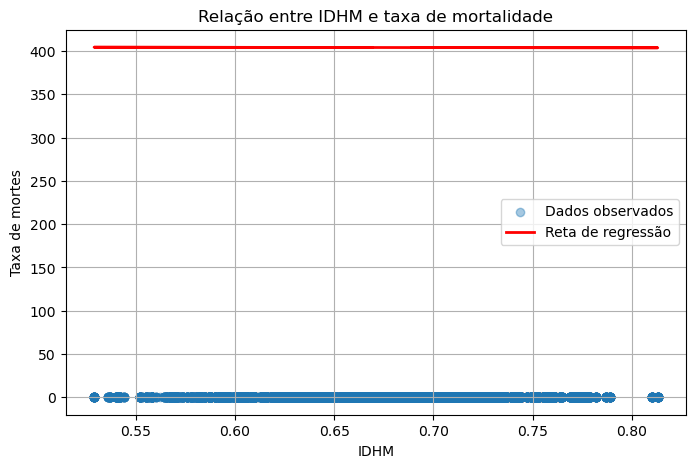

In [158]:
x = df_reg['idhm']
y = df_reg['taxa_mortes']


y_pred = modelo.predict(sm.add_constant(x))

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.4, label='Dados observados')
plt.plot(x, y_pred, color='red', linewidth=2, label='Reta de regressão')
plt.xlabel('IDHM')
plt.ylabel('Taxa de mortes')
plt.title('Relação entre IDHM e taxa de mortalidade')
plt.legend()
plt.grid(True)
plt.show()

## Avaliação da taxa de mortalidade infantil pelo pib per capta

In [157]:
df = df_join[['taxa_de_mortalidade_infantil', 'pibpercapita_mil']].dropna()
X = sm.add_constant(df['pibpercapita_mil'])
y = df['taxa_de_mortalidade_infantil']
modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                                 OLS Regression Results                                 
Dep. Variable:     taxa_de_mortalidade_infantil   R-squared:                       0.001
Model:                                      OLS   Adj. R-squared:                  0.001
Method:                           Least Squares   F-statistic:                     10.95
Date:                          Fri, 31 Oct 2025   Prob (F-statistic):           0.000937
Time:                                  13:28:04   Log-Likelihood:                -84754.
No. Observations:                         10251   AIC:                         1.695e+05
Df Residuals:                             10249   BIC:                         1.695e+05
Df Model:                                     1                                         
Covariance Type:                      nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------

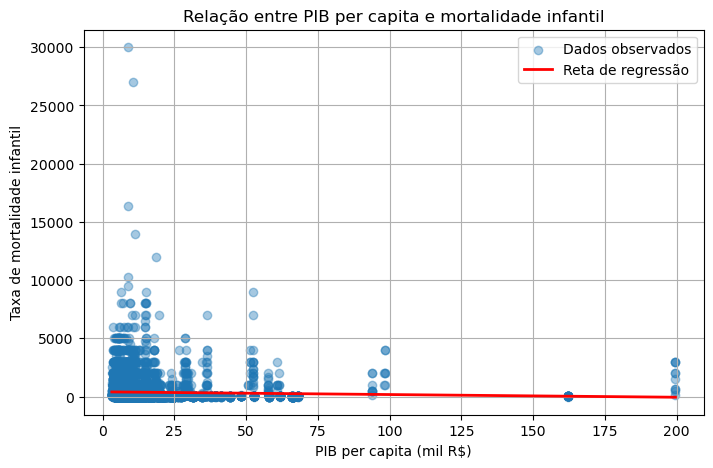

In [163]:
x = df['pibpercapita_mil']
y = df['taxa_de_mortalidade_infantil']

y_pred = modelo.predict(sm.add_constant(x))


plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.4, label='Dados observados')
plt.plot(np.sort(x), modelo.predict(sm.add_constant(np.sort(x))), color='red', linewidth=2, label='Reta de regressão')

plt.xlabel('PIB per capita (mil R$)')
plt.ylabel('Taxa de mortalidade infantil')
plt.title('Relação entre PIB per capita e mortalidade infantil')
plt.legend()
plt.grid(True)
plt.show()

## Visualizações gráficas - Séries temporais nos municípios supracitados

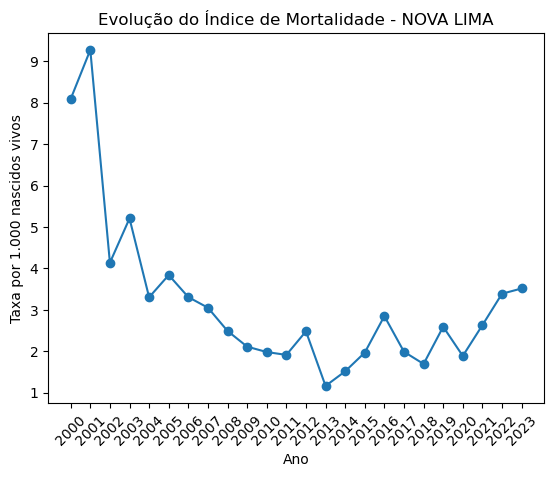

In [300]:
df_araponga = df_join[df_join["nome_do_municipio"] == "NOVA LIMA"]
plt.plot(df_araponga["ANO"], df_araponga["taxa_de_mortalidade_infantil"], marker='o')
plt.title("Evolução do Índice de Mortalidade - NOVA LIMA")
plt.xlabel("Ano")
plt.ylabel("Taxa por 1.000 nascidos vivos")
plt.xticks(rotation=45)
plt.show()

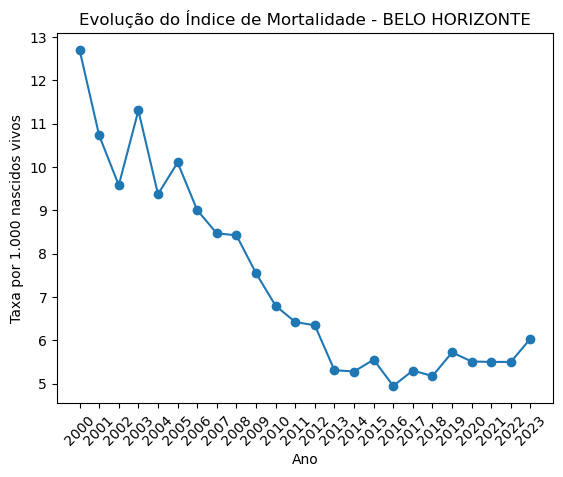

In [301]:
df_araponga = df_join[df_join["nome_do_municipio"] == "BELO HORIZONTE"]
plt.plot(df_araponga["ANO"], df_araponga["taxa_de_mortalidade_infantil"], marker='o')
plt.title("Evolução do Índice de Mortalidade - BELO HORIZONTE")
plt.xlabel("Ano")
plt.ylabel("Taxa por 1.000 nascidos vivos")
plt.xticks(rotation=45)
plt.show()

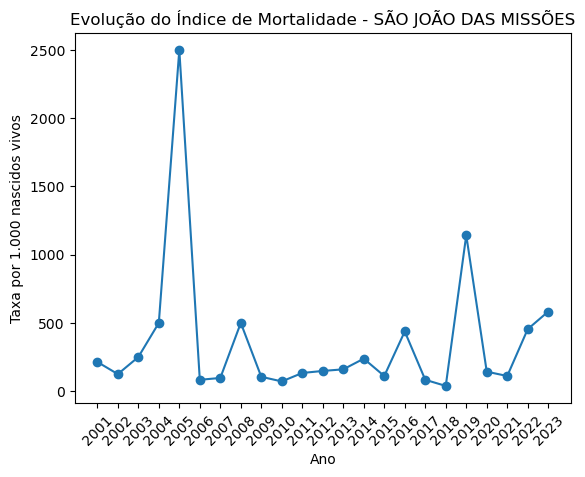

In [302]:
df_araponga = df_join[df_join["nome_do_municipio"] == "SÃO JOÃO DAS MISSÕES"]
plt.plot(df_araponga["ANO"], df_araponga["taxa_de_mortalidade_infantil"], marker='o')
plt.title("Evolução do Índice de Mortalidade - SÃO JOÃO DAS MISSÕES")
plt.xlabel("Ano")
plt.ylabel("Taxa por 1.000 nascidos vivos")
plt.xticks(rotation=45)
plt.show()

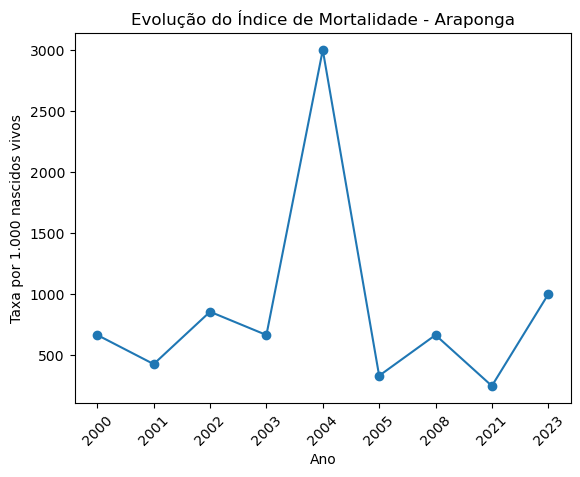

In [303]:
df_araponga = df_join[df_join["nome_do_municipio"] == "ARAPONGA"]
plt.plot(df_araponga["ANO"], df_araponga["taxa_de_mortalidade_infantil"], marker='o')
plt.title("Evolução do Índice de Mortalidade - Araponga")
plt.xlabel("Ano")
plt.ylabel("Taxa por 1.000 nascidos vivos")
plt.xticks(rotation=45)
plt.show()

## Gráfico de dispersão - nascimentos x óbitos 

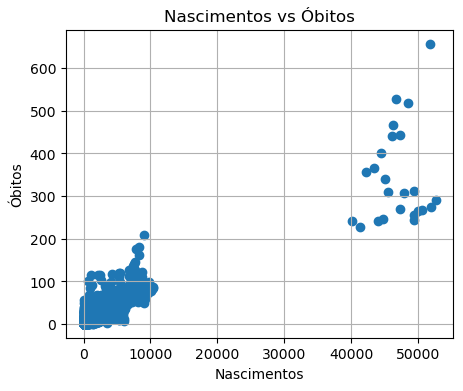

In [304]:
plt.figure(figsize=(5,4))
plt.scatter(df_join["n_nascimentos"], df_join["n_obitos"])
plt.title("Nascimentos vs Óbitos")
plt.xlabel("Nascimentos"); plt.ylabel("Óbitos"); plt.grid(True, axis="both")
plt.show()